<a href="https://colab.research.google.com/github/lukianenkoromanfb61mp-ui/IAD/blob/main/1_1Lukianenko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Завдання 1 практичної роботи 1.**

1. Імпорти.

In [2]:
import urllib.request, zipfile, io
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
sns.set_style("whitegrid"); RS = 42

2. Отримання датасету.

In [5]:
url = "https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip"
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    print(zf.namelist())                         # подивитись вміст
    name = [n for n in zf.namelist() if n.endswith('.xlsx')][0]
    df = pd.read_excel(zf.open(name))

print(df.shape); display(df.head())

['DryBeanDataset/', 'DryBeanDataset/Dry_Bean_Dataset.arff', 'DryBeanDataset/Dry_Bean_Dataset.txt', 'DryBeanDataset/Dry_Bean_Dataset.xlsx']
(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


3. Первинний аналіз.

In [6]:
print(df.columns.tolist())
print(df.dtypes.value_counts())
print("\nПропуски:", df.isnull().sum().sum())
print("\nКласи:"); print(df['Class'].value_counts())

['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']
float64    14
int64       2
object      1
Name: count, dtype: int64

Пропуски: 0

Класи:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


4. Обробка.

In [7]:
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
print(dict(zip(le.classes_, range(len(le.classes_)))))

{'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


5. EDA

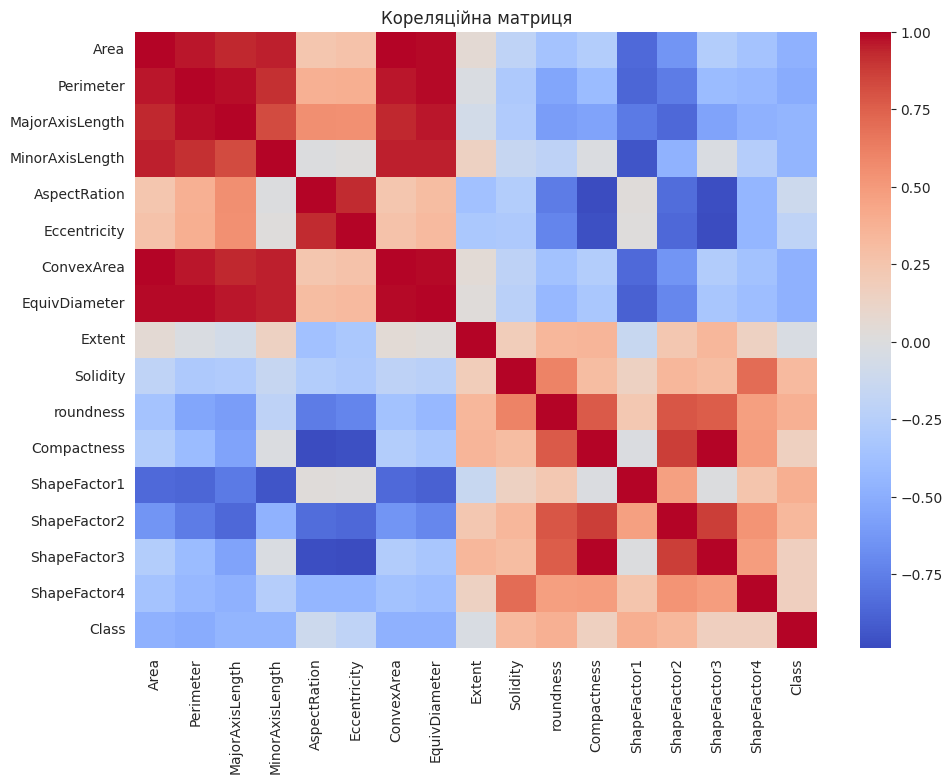

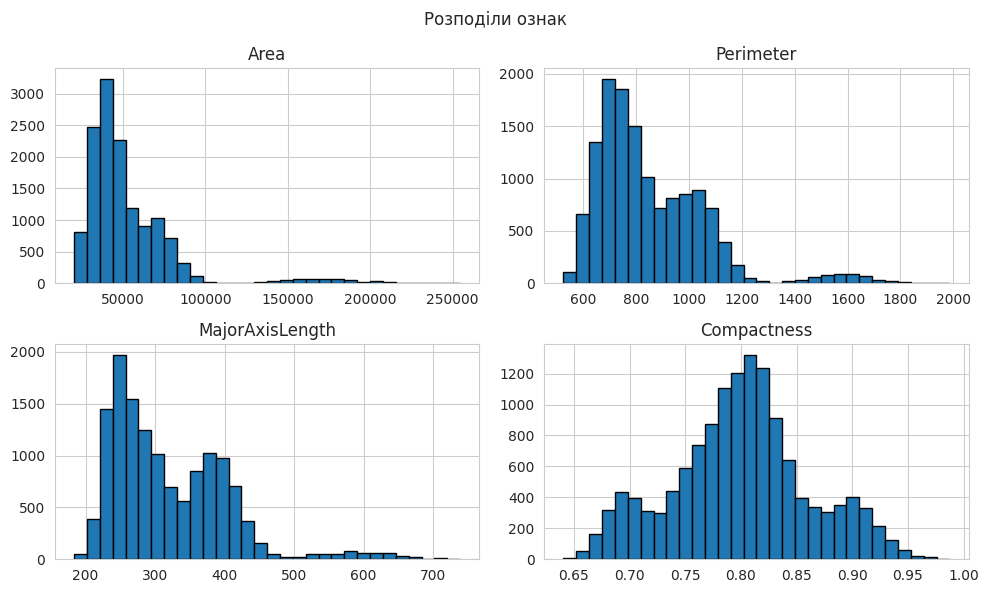

/tmp/ipykernel_1900/2279947878.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=c, data=df, ax=a, palette='Set2')
/tmp/ipykernel_1900/2279947878.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=c, data=df, ax=a, palette='Set2')
/tmp/ipykernel_1900/2279947878.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=c, data=df, ax=a, palette='Set2')
/tmp/ipykernel_1900/2279947878.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the 

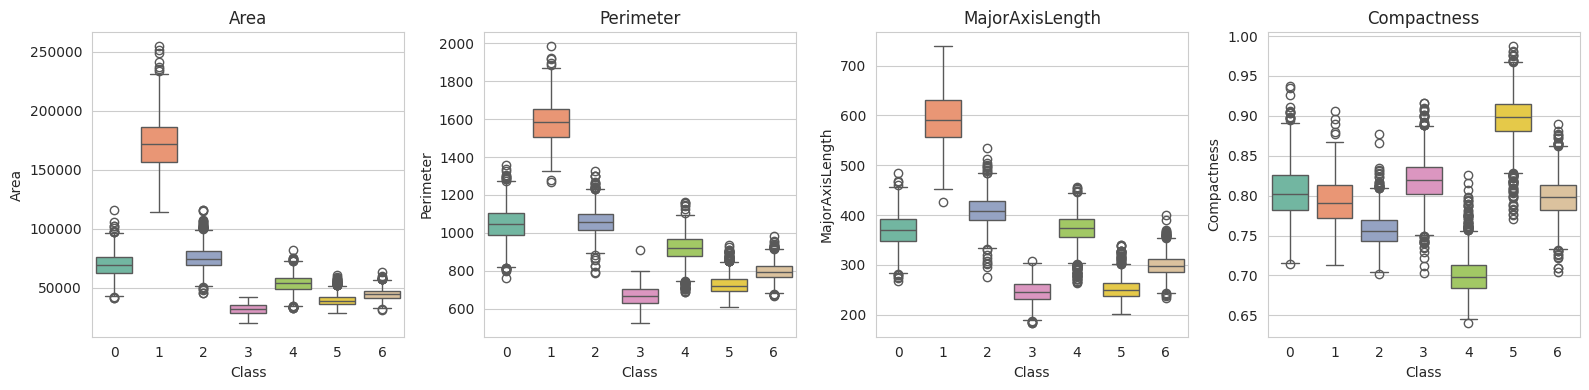

In [8]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Кореляційна матриця"); plt.show()

cols = ['Area','Perimeter','MajorAxisLength','Compactness']
df[cols].hist(figsize=(10,6), bins=30, edgecolor='black')
plt.suptitle("Розподіли ознак"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, c in zip(ax, cols):
    sns.boxplot(x='Class', y=c, data=df, ax=a, palette='Set2')
    a.set_title(c)
plt.tight_layout(); plt.show()

6. Train/Test і маштабування.

In [10]:
X = df.drop('Class', axis=1); y = df['Class']
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=RS, stratify=y)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)
print(X_tr_s.shape, X_te_s.shape)

(10208, 16) (3403, 16)


7. Оголошення 5-ти базових моделей.

In [11]:
models = {
    'kNN': KNeighborsClassifier(),
    'Tree': DecisionTreeClassifier(random_state=RS),
    'SVM': SVC(random_state=RS),
    'RF': RandomForestClassifier(random_state=RS),
    'AdaBoost': AdaBoostClassifier(random_state=RS),
}
for n, m in models.items():
    m.fit(X_tr_s, y_tr)
    print(f"\n=== {n} === acc = {accuracy_score(y_te, m.predict(X_te_s)):.4f}")


=== kNN === acc = 0.9174

=== Tree === acc = 0.8927

=== SVM === acc = 0.9254

=== RF === acc = 0.9186

=== AdaBoost === acc = 0.8393


8. Підбір гіперпараметрів.

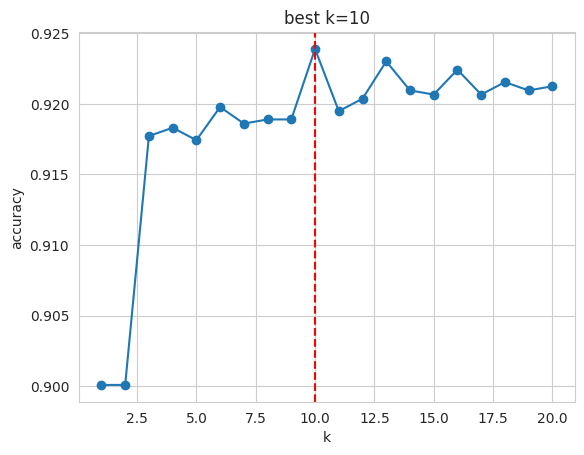

Best SVM: {'C': 10, 'gamma': 'scale'} CV acc: 0.9325


In [12]:
accs = [accuracy_score(y_te,
        KNeighborsClassifier(n_neighbors=k).fit(X_tr_s, y_tr).predict(X_te_s))
        for k in range(1, 21)]
best_k = int(np.argmax(accs)) + 1
plt.plot(range(1,21), accs, marker='o'); plt.axvline(best_k, color='r', ls='--')
plt.xlabel('k'); plt.ylabel('accuracy'); plt.title(f'best k={best_k}'); plt.show()

grid = GridSearchCV(SVC(random_state=RS),
                    {'C':[0.1,1,10,100], 'gamma':['scale',0.01,0.1,1]},
                    cv=3, n_jobs=-1, scoring='accuracy')
grid.fit(X_tr_s, y_tr)
print("Best SVM:", grid.best_params_, "CV acc:", round(grid.best_score_,4))
best_svm = grid.best_estimator_

9. Фінальне порівняння.


=== kNN (tuned) ===  acc = 0.9239
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.91      0.93       330
      BOMBAY       1.00      1.00      1.00       130
        CALI       0.94      0.95      0.95       408
    DERMASON       0.91      0.92      0.91       887
       HOROZ       0.96      0.95      0.96       482
       SEKER       0.94      0.95      0.94       507
        SIRA       0.86      0.87      0.86       659

    accuracy                           0.92      3403
   macro avg       0.94      0.94      0.94      3403
weighted avg       0.92      0.92      0.92      3403

[[299   0  16   0   1   6   8]
 [  0 130   0   0   0   0   0]
 [  7   0 389   0   7   2   3]
 [  0   0   0 815   0  17  55]
 [  0   0   9   4 459   0  10]
 [  2   0   0   9   0 481  15]
 [  2   0   1  67  10   8 571]]

=== Tree ===  acc = 0.8927
              precision    recall  f1-score   support

    BARBUNYA       0.90      0.88      0.89       330
      BOMBAY 

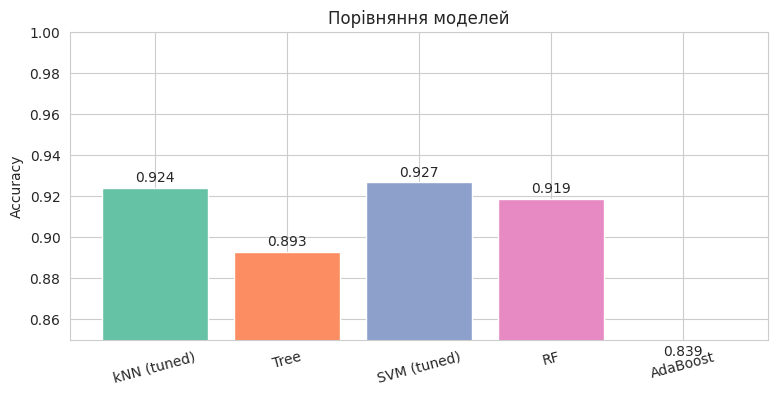

In [13]:
final = {
    'kNN (tuned)': KNeighborsClassifier(n_neighbors=best_k),
    'Tree':        DecisionTreeClassifier(random_state=RS),
    'SVM (tuned)': best_svm,
    'RF':          RandomForestClassifier(random_state=RS),
    'AdaBoost':    AdaBoostClassifier(random_state=RS),
}
res = {}
for n, m in final.items():
    m.fit(X_tr_s, y_tr)
    y_p = m.predict(X_te_s)
    res[n] = accuracy_score(y_te, y_p)
    print(f"\n=== {n} ===  acc = {res[n]:.4f}")
    print(classification_report(y_te, y_p, target_names=le.classes_))
    print(confusion_matrix(y_te, y_p))

plt.figure(figsize=(9,4))
bars = plt.bar(res.keys(), res.values(), color=sns.color_palette("Set2", 5))
for b, v in zip(bars, res.values()):
    plt.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.3f}", ha='center')
plt.ylim(0.85, 1.0); plt.ylabel('Accuracy')
plt.title('Порівняння моделей'); plt.xticks(rotation=15); plt.show()